# Table of Contents

1. Introduction
2. Import Libraries
3. Load Dataset
4. Dataset Overview
5. Data Cleaning
6. Exploratory Data Analysis
   - Monthly Sales Trend
   - Customer Segment Analysis
   - Regional Sales Analysis
   - Category Analysis
   - Sub-Category Analysis
   - Top 10 Products
   - Correlation Heatmap
   - Top 10 States by Sales
   - Sales Distribution
7. Business Recommendations
8. Conclusion

# Exploratory Data Analysis (EDA) on Retail Sales Data

## Objective

The objective of this project is to perform Exploratory Data Analysis (EDA) on a retail sales dataset to identify sales trends, customer behavior, product performance, and generate meaningful business insights using Python.

### Tools Used
- Python
- Pandas
- Matplotlib
- Seaborn
- Jupyter Notebook


In [ ]:
# Import required libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside the notebook
%matplotlib inline

In [ ]:
df = pd.read_csv("train.csv")

In [ ]:
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [ ]:
# Display the first 5 rows

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08-11-2017,11-11-2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08-11-2017,11-11-2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12-06-2017,16-06-2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11-10-2016,18-10-2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11-10-2016,18-10-2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [ ]:
df.shape

(9800, 18)

In [ ]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='str')

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

In [ ]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)

In [ ]:
# Create new columns from Order Date

df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month_name()
df["Quarter"] = df["Order Date"].dt.quarter
df["Year_Month"] = df["Order Date"].dt.to_period("M").astype(str)

In [ ]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Year', 'Month', 'Quarter', 'Year_Month'],
      dtype='str')

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   str           
 2   Order Date     9800 non-null   datetime64[us]
 3   Ship Date      9800 non-null   datetime64[us]
 4   Ship Mode      9800 non-null   str           
 5   Customer ID    9800 non-null   str           
 6   Customer Name  9800 non-null   str           
 7   Segment        9800 non-null   str           
 8   Country        9800 non-null   str           
 9   City           9800 non-null   str           
 10  State          9800 non-null   str           
 11  Postal Code    9789 non-null   float64       
 12  Region         9800 non-null   str           
 13  Product ID     9800 non-null   str           
 14  Category       9800 non-null   str           
 15  Sub-Category   9800 non-null   s

In [ ]:
df.duplicated().sum()

np.int64(0)

## 6.1 Monthly Sales Analysis

In this section, we analyze the total sales generated in each month to identify seasonal trends and peak sales periods.

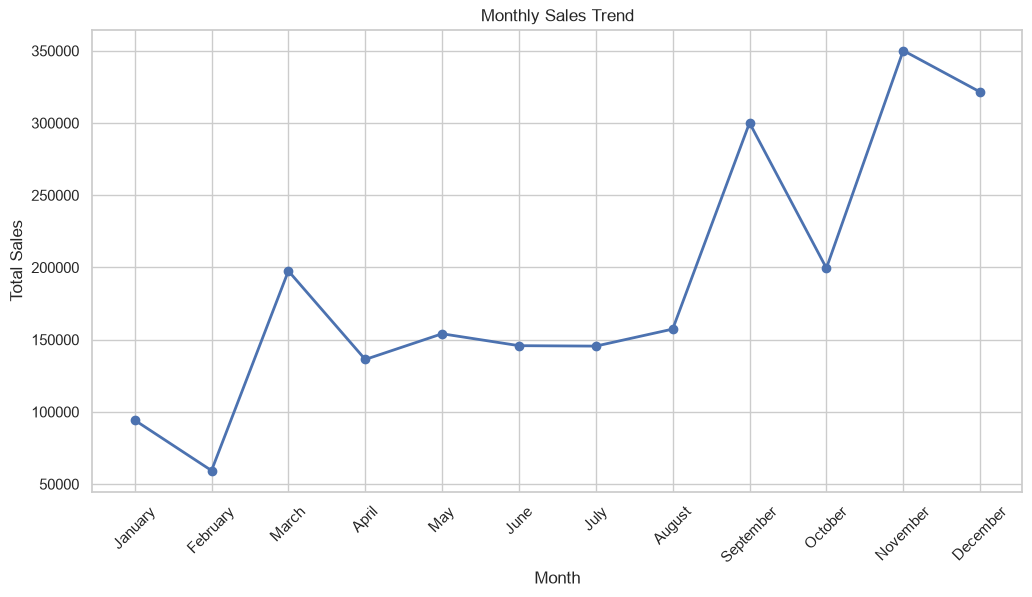

In [ ]:
# Monthly Sales Analysis

monthly_sales = df.groupby("Month")["Sales"].sum()

# Arrange months in calendar order
month_order = ["January", "February", "March", "April", "May", "June",
               "July", "August", "September", "October", "November", "December"]

monthly_sales = monthly_sales.reindex(month_order)

plt.figure(figsize=(12,6))

plt.plot(monthly_sales.index,
         monthly_sales.values,
         marker='o',
         linewidth=2)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

### Observation

- Sales remain relatively moderate from April to August.
- February records the lowest sales among all months.
- A significant increase in sales is observed from September onwards.
- November records the highest sales, indicating a strong year-end sales period.
- Sales decline slightly in December but remain higher than most other months.

These trends suggest that customer purchasing activity increases considerably during the final quarter of the year, possibly due to festive seasons, promotional campaigns, or holiday shopping.

## 6.2 Customer Segment Analysis

Customer segmentation helps businesses understand which customer groups contribute the most to overall sales. This analysis compares sales across different customer segments.

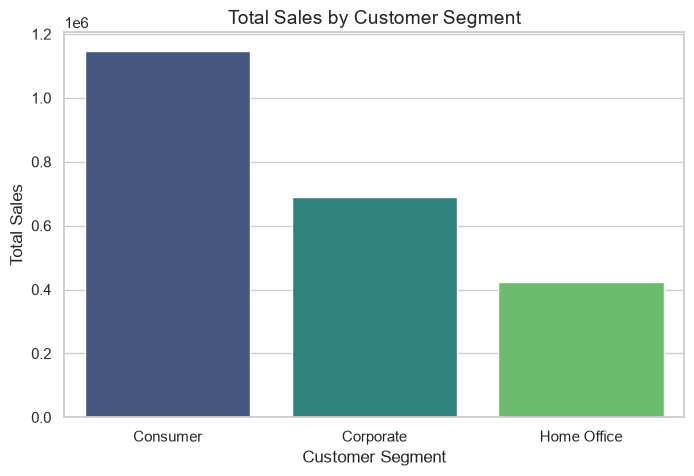

In [ ]:
# Sales by Customer Segment

segment_sales = df.groupby("Segment")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))

sns.barplot(
    x=segment_sales.index,
    y=segment_sales.values,
    hue=segment_sales.index,
    palette="viridis",
    legend=False
)

plt.title("Total Sales by Customer Segment", fontsize=14)

plt.xlabel("Customer Segment")

plt.ylabel("Total Sales")

plt.show()

### Observation

- The Consumer segment generates the highest total sales, contributing over 1.1 million in revenue.
- The Corporate segment is the second-largest contributor with around 0.69 million in sales.
- The Home Office segment contributes the least, generating approximately 0.43 million in sales.
- This indicates that the Consumer segment is the primary customer base and should remain the focus of marketing and customer retention strategies.
- The company can explore targeted campaigns and special offers for the Home Office segment to improve its sales contribution.

## 6.3 Regional Sales Analysis

This analysis helps identify which geographical regions contribute the most to overall sales and highlights opportunities for regional growth.

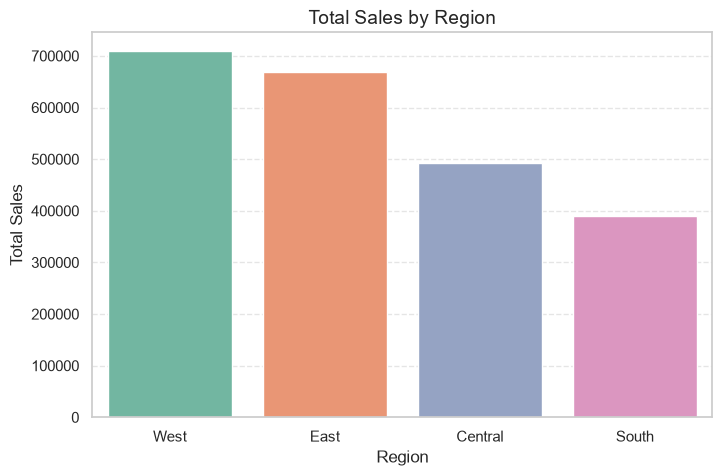

In [ ]:
region_sales = (
    df.groupby("Region")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=region_sales.index,
    y=region_sales.values,
    hue=region_sales.index,
    palette="Set2",
    legend=False
)

plt.title("Total Sales by Region", fontsize=14)

plt.xlabel("Region")

plt.ylabel("Total Sales")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

### Observation

- The West region records the highest total sales, contributing approximately 0.71 million.
- The East region follows closely with around 0.67 million in total sales.
- The Central region generates moderate sales, while the South region has the lowest sales among all regions.
- The strong performance of the West and East regions indicates a higher customer demand or better market penetration.
- The South region presents an opportunity for the business to increase sales through targeted marketing campaigns, improved distribution, or promotional strategies.

## 6.4 Sales by Product Category

This analysis compares total sales across different product categories to identify which categories contribute the most revenue.

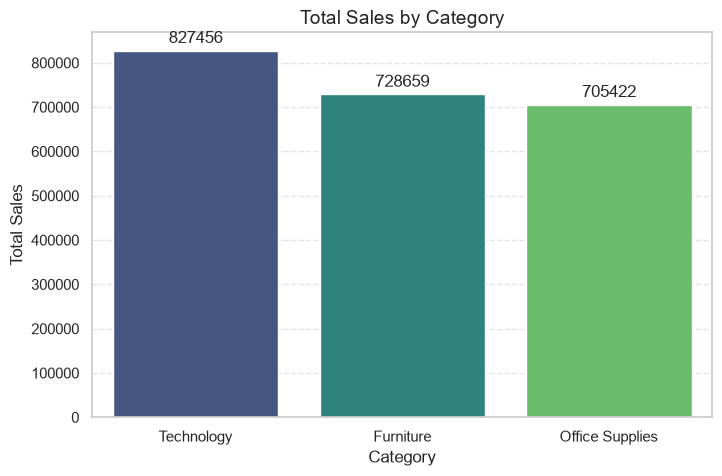

In [ ]:
category_sales = (
    df.groupby("Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=category_sales.index,
    y=category_sales.values,
    hue=category_sales.index,
    palette="viridis",
    legend=False
)

plt.title("Total Sales by Category", fontsize=14)
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.grid(axis="y", linestyle="--", alpha=0.5)

# Add values on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)

plt.show()

### Observation

- The Technology category generates the highest total sales, contributing more than 0.82 million.
- Furniture is the second-highest revenue-generating category.
- Office Supplies also contributes significantly, with sales close to Furniture.
- The relatively small difference between Furniture and Office Supplies suggests consistent customer demand across these categories.
- The Technology category appears to be the company's strongest product category and should continue to receive focus in marketing and inventory planning.

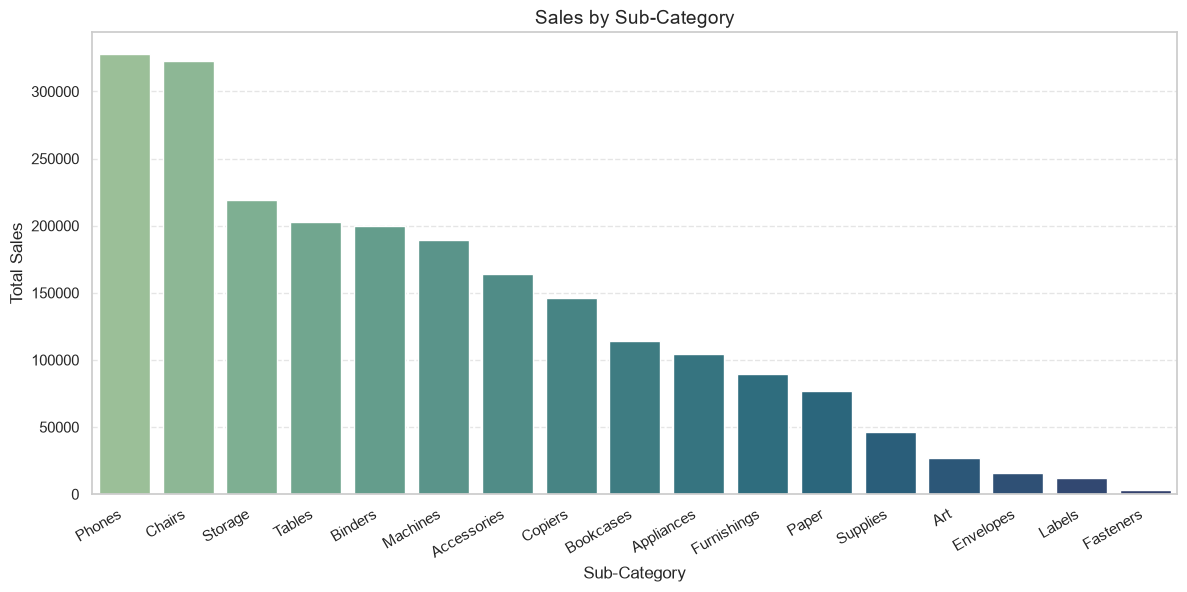

In [ ]:
subcategory_sales = (
    df.groupby("Sub-Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(14,6))

sns.barplot(
    x=subcategory_sales.index,
    y=subcategory_sales.values,
    hue=subcategory_sales.index,
    palette="crest",
    legend=False
)

plt.title("Sales by Sub-Category", fontsize=14)

plt.xlabel("Sub-Category")

plt.ylabel("Total Sales")

plt.xticks(rotation=30, ha='right')

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

### Observation

- Phones generate the highest total sales among all sub-categories, followed closely by Chairs.
- Storage, Tables, Binders, and Machines also contribute significantly to overall revenue.
- Fasteners, Labels, and Envelopes generate the lowest sales, indicating lower customer demand.
- The wide variation in sales across sub-categories suggests that customer preferences differ considerably by product type.
- The company should continue promoting high-performing products like Phones and Chairs while reviewing the marketing strategy for low-performing sub-categories.

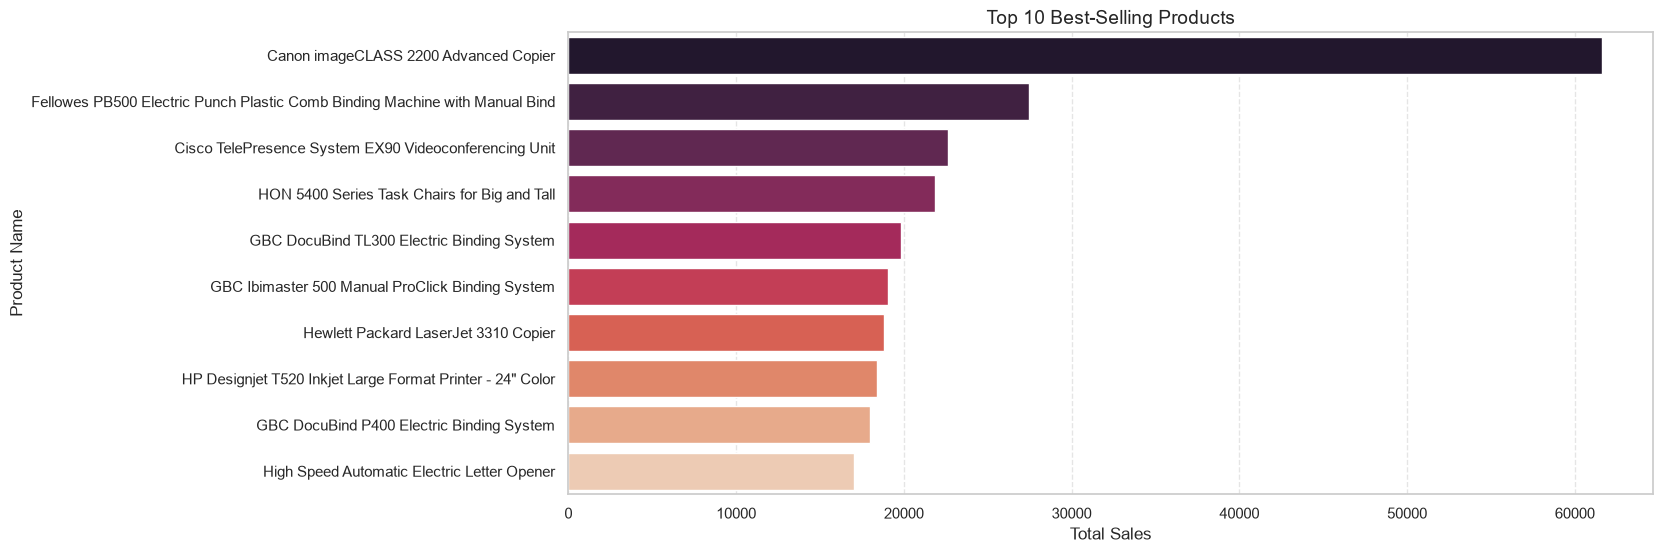

In [ ]:
top_products = (
    df.groupby("Product Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(14,6))

sns.barplot(
    x=top_products.values,
    y=top_products.index,
    hue=top_products.index,
    palette="rocket",
    legend=False
)

plt.title("Top 10 Best-Selling Products", fontsize=14)

plt.xlabel("Total Sales")

plt.ylabel("Product Name")

plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.show()

### Observation

- The Canon imageCLASS 2200 Advanced Copier is the highest-selling product by a significant margin, generating over 60,000 in sales.
- The Fellowes PB500 Electric Punch Plastic Comb Binding Machine ranks second, followed by the Cisco TelePresence System EX90.
- Most of the top-selling products belong to technology and office equipment categories.
- The noticeable gap between the highest-selling product and the remaining products indicates that a few premium products contribute significantly to overall revenue.
- The company should ensure adequate inventory and promotional focus for these high-performing products while analyzing factors behind their success.

## 6.5 Correlation Heatmap

A correlation heatmap helps identify relationships between numerical variables in the dataset.

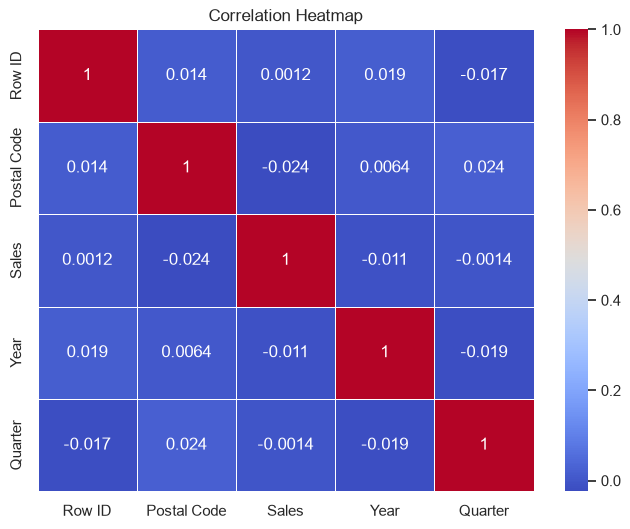

In [ ]:
numeric_df = df.select_dtypes(include=["number"])

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

### Observation

- The heatmap shows very weak correlations among the numerical variables.
- Sales have almost no linear relationship with the available numeric features.
- Row ID and Postal Code are identifier-based fields and do not contribute meaningful business insights.
- Since most important variables (such as Category, Region, and Customer Segment) are categorical, they are not represented in this correlation analysis.

## 6.7 Top 10 States by Sales

This visualization identifies the states contributing the highest sales, helping understand geographical demand patterns.

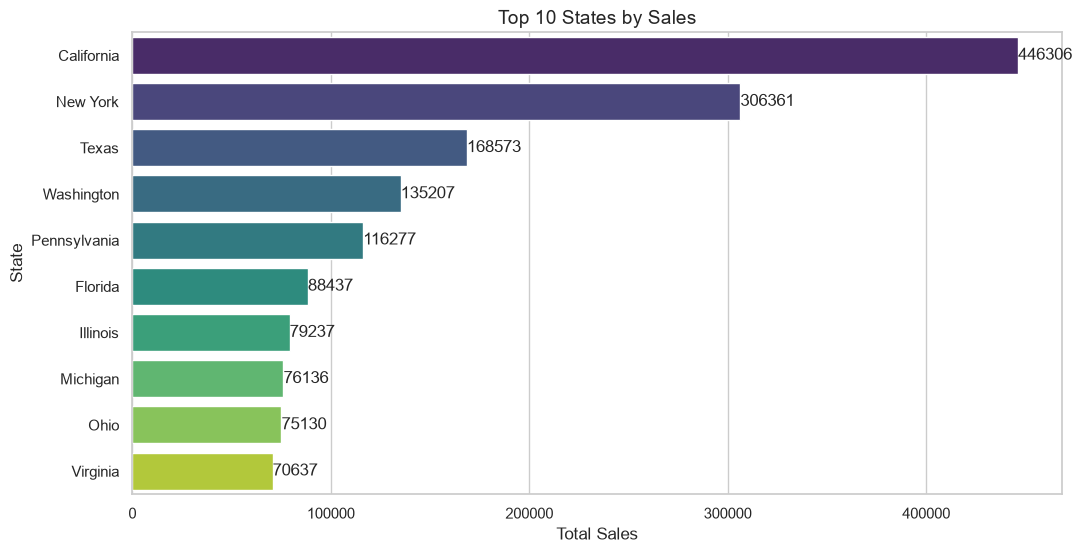

In [ ]:
top_states = (
    df.groupby("State")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=top_states.values,
    y=top_states.index,
    hue=top_states.index,
    palette="viridis",
    legend=False
)

plt.title("Top 10 States by Sales", fontsize=14)

plt.xlabel("Total Sales")

plt.ylabel("State")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.show()

### Observation

- California generates the highest sales, contributing approximately **446,306**, making it the strongest-performing state.
- New York ranks second with around **306,361** in total sales.
- Texas and Washington also contribute significantly but remain well below California.
- The large gap between California and the remaining states indicates a highly concentrated sales market.
- The company should continue strengthening its presence in top-performing states while identifying strategies to improve sales in lower-performing regions.

## 6.8 Sales Distribution

This visualization shows how sales values are distributed across all transactions and helps identify skewness and outliers.

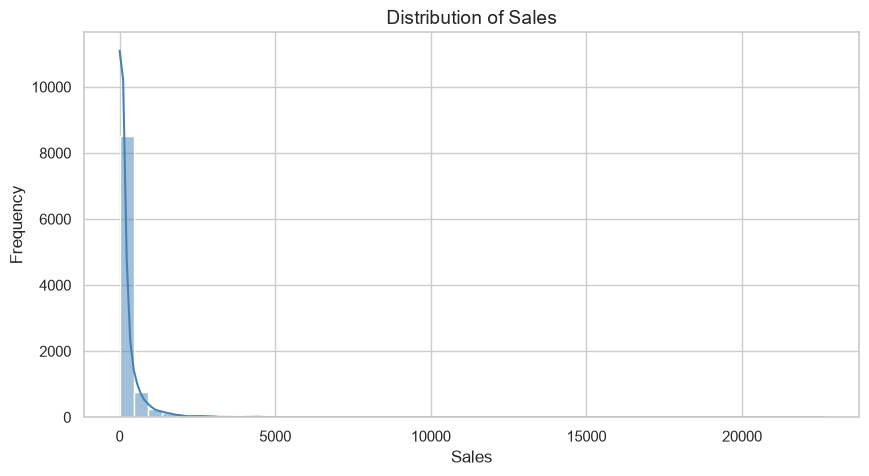

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(df["Sales"], bins=50, kde=True, color="steelblue")

plt.title("Distribution of Sales", fontsize=14)

plt.xlabel("Sales")

plt.ylabel("Frequency")

plt.show()

### Observation

- The sales distribution is highly right-skewed (positively skewed).
- Most transactions have relatively low sales values, indicating that small-value orders occur much more frequently.
- A small number of transactions have exceptionally high sales, creating a long right tail in the distribution.
- These high-value transactions act as outliers and contribute significantly to the overall revenue.
- This distribution is common in retail businesses, where many small purchases are complemented by a few large orders.

# Business Recommendations

1. Increase investment in the Technology category as it generates the highest revenue.

2. Continue focusing on the Consumer segment while designing promotional campaigns for the Home Office segment.

3. Strengthen sales efforts in the South region through targeted marketing.

4. Maintain sufficient inventory for high-selling products such as the Canon imageCLASS 2200 Advanced Copier.

5. Analyze successful strategies in California and New York and apply similar approaches in lower-performing states.

# Conclusion

This project performed Exploratory Data Analysis (EDA) on a retail sales dataset to understand sales patterns, customer segments, product performance, and regional trends.

The analysis showed that:
- The Technology category generated the highest sales.
- Consumer customers contributed the largest share of revenue.
- The West region, particularly California, recorded the highest sales.
- Sales increased significantly during the fourth quarter, indicating seasonal demand.
- A few high-value orders contributed disproportionately to total revenue, resulting in a positively skewed sales distribution.

Lastly, the insights obtained from this analysis can help businesses optimize inventory management, improve marketing strategies, and make informed data-driven decisions.